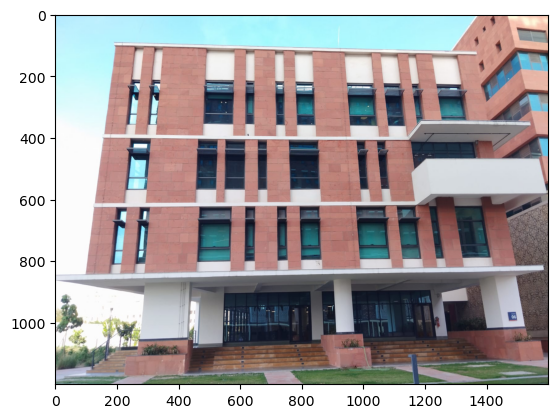

In [6]:
from PIL import Image 
import matplotlib.pyplot as plt
# creating a object 
im = Image.open(r"A2 images/BaseImage_A2.jpeg") 
plt.imshow(im)
plt.show()

Manually annotated with MS paint by looking at what pixels are corners.

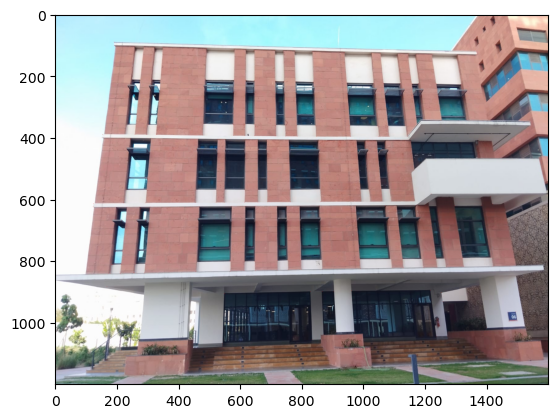

334 number of annotated corners found
[[   3 1422]
 [  17 1411]
 [  28 1429]
 [  37 1395]
 [  42 1497]
 [  46 1388]
 [  50 1397]
 [  53 1592]
 [  72 1369]
 [  83 1360]
 [  84 1442]
 [  85 1509]
 [  91  192]
 [  96 1375]
 [  99 1428]
 [ 102  192]
 [ 106  257]
 [ 106  289]
 [ 108  322]
 [ 108  351]
 [ 112  491]
 [ 113  582]
 [ 116  618]
 [ 116 1449]
 [ 117  648]
 [ 118  713]
 [ 119  742]
 [ 119  777]
 [ 120 1367]
 [ 122  836]
 [ 124  939]
 [ 127 1028]
 [ 127 1056]
 [ 129 1146]
 [ 130 1172]
 [ 131 1223]
 [ 131 1369]
 [ 132 1306]
 [ 147 1388]
 [ 161 1376]
 [ 177 1395]
 [ 211  488]
 [ 213  250]
 [ 213  276]
 [ 213  316]
 [ 213  341]
 [ 213  581]
 [ 214  618]
 [ 215  647]
 [ 217  715]
 [ 218  743]
 [ 219  255]
 [ 219  275]
 [ 219  781]
 [ 220  320]
 [ 220  341]
 [ 220  838]
 [ 223  947]
 [ 224  258]
 [ 224  275]
 [ 224 1033]
 [ 224 1066]
 [ 224 1120]
 [ 225  323]
 [ 226 1159]
 [ 226 1179]
 [ 226 1237]
 [ 228  948]
 [ 229 1317]
 [ 230 1029]
 [ 252  489]
 [ 254  579]
 [ 254  622]
 [ 254  645]


In [7]:
import cv2
import numpy as np

# Load image (OpenCV loads in BGR format)
image = cv2.imread("A2 images/GroundtruthImage_A2.png")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.show()

target = np.array([255, 0, 0])

matches = np.all(image_rgb == target, axis=-1)

coords_ground_truth = np.column_stack(np.where(matches))
print(f"{len(coords_ground_truth)} number of annotated corners found")
print(coords_ground_truth)

5098 number of annotated corners found for 0.005*max threshold
3672 number of annotated corners found for 0.0075*max threshold
2823 number of annotated corners found for 0.01*max threshold
1252 number of annotated corners found for 0.025*max threshold
657 number of annotated corners found for 0.05*max threshold
450 number of annotated corners found for 0.075*max threshold
330 number of annotated corners found for 0.1*max threshold
112 number of annotated corners found for 0.25*max threshold
42 number of annotated corners found for 0.5*max threshold
12 number of annotated corners found for 0.75*max threshold


<Figure size 1000x800 with 0 Axes>

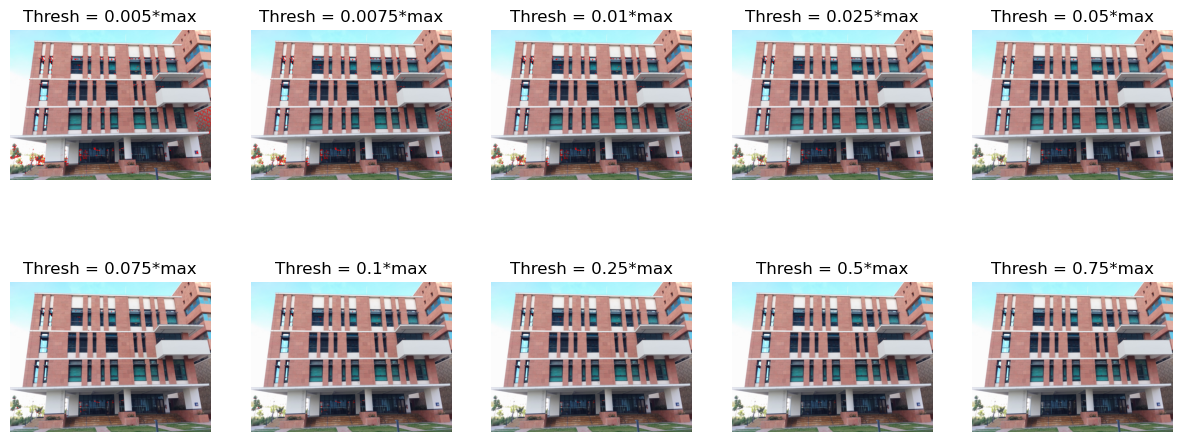

In [ ]:
import numpy as np
import cv2 as cv
 
filename = "A2 images/BaseImage_A2.jpeg"
img = cv.imread(filename)
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
 
gray = np.float32(gray)
dst = cv.cornerHarris(gray,2,3,0.04)
#result is dilated for marking the corners, not important
# dst = cv.dilate(dst,None)
Thresholds = [0.005,0.0075,0.01,0.025,0.05,0.075,0.1,0.25,0.5,0.75] 
coords_array = []

target = np.array([0, 0, 255])
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i,thresh in enumerate(Thresholds):
	dst = cv.cornerHarris(gray,2,3,0.04) # response map
	image_copy = cv.imread(filename)
	image_copy[dst>thresh*dst.max()]=[0,0,255]
	matches = np.all(image_copy == target, axis=-1)
	coords_Harris = np.column_stack(np.where(matches))
	print(f"{len(coords_Harris)} number of annotated corners found for {thresh}*max threshold")
	coords_array.append(coords_Harris)
	dst = cv.dilate(dst,None)
	image_copy[dst>thresh*dst.max()]=[0,0,255]
	axes[i].imshow(cv.cvtColor(image_copy, cv.COLOR_BGR2RGB))
	axes[i].set_title(f'Thresh = {thresh}*max')
	axes[i].axis('off')

In [10]:
from math import sqrt
def is_within_margin(point,ground_truth,margin=3):
	min_dist = 10000000
	min_point = []
	for item in ground_truth:
		dist = sqrt((point[0]-item[0])**2+(point[1]-item[1])**2)
		if dist<=margin:
			# print(point,item,dist)
			return True
		if dist<min_dist:
			min_dist = dist
			min_point = item
	# print(f"closest point to  {point} was {min_point} with dist = {min_dist}")
	return False

def num_truePos (points,ground_truth):
	# we coundting the number of points in prediction that are close to ground truth points
	num = 0
	for point in points:
		if is_within_margin(point,ground_truth.tolist()):
			num+=1
	return num

test =  coords_array[0]
print(num_truePos(test,coords_ground_truth))

def num_falseNeg(points,ground_truth):
	# we counting number of points in ground truth that are not close to any prediction points
	num = 0
	for point in ground_truth:
		if not(is_within_margin(point,points)):
			num+=1
	return num

print(num_falseNeg(test,coords_ground_truth))


711
143


In [11]:
# getting precision and recall for each thing.
for i,thresh_points in enumerate(coords_array):
	thresh = Thresholds[i]
	total_predictions = len(thresh_points)
	true_positves = num_truePos(thresh_points,coords_ground_truth)
	false_negatives = num_falseNeg(thresh_points,coords_ground_truth)
	false_positives = total_predictions - true_positves
	precision = true_positves/(true_positves+false_positives)
	recall = true_positves/(true_positves+false_negatives)
	print("====================================")
	print(f"For threshold of {thresh}:")
	print(f"TP: {true_positves}, FP: {false_positives}, FN: {false_negatives}")
	print(f"Precision = {precision}")
	print(f"Recall = {recall}")
	print(f"total predictions = {total_predictions}")


For threshold of 0.005:
TP: 711, FP: 4387, FN: 143
Precision = 0.13946645743428795
Recall = 0.832552693208431
total predictions = 5098
For threshold of 0.0075:
TP: 557, FP: 3115, FN: 170
Precision = 0.1516884531590414
Recall = 0.7661623108665749
total predictions = 3672
For threshold of 0.01:
TP: 432, FP: 2391, FN: 187
Precision = 0.153028692879915
Recall = 0.6978998384491115
total predictions = 2823
For threshold of 0.025:
TP: 200, FP: 1052, FN: 254
Precision = 0.1597444089456869
Recall = 0.44052863436123346
total predictions = 1252
For threshold of 0.05:
TP: 96, FP: 561, FN: 289
Precision = 0.1461187214611872
Recall = 0.24935064935064935
total predictions = 657
For threshold of 0.075:
TP: 63, FP: 387, FN: 305
Precision = 0.14
Recall = 0.17119565217391305
total predictions = 450
For threshold of 0.1:
TP: 44, FP: 286, FN: 315
Precision = 0.13333333333333333
Recall = 0.12256267409470752
total predictions = 330
For threshold of 0.25:
TP: 13, FP: 99, FN: 325
Precision = 0.1160714285714285

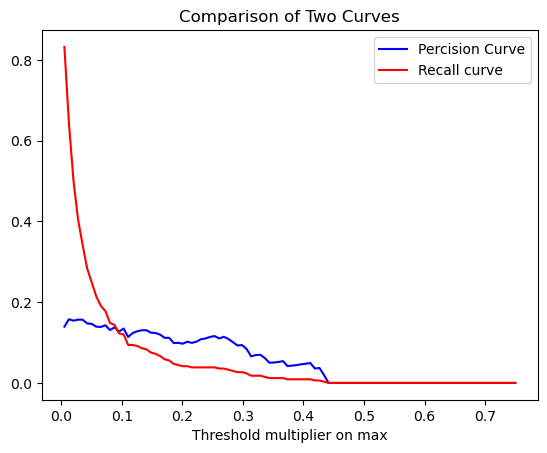

[0.13946645743428795, 0.15787215787215786, 0.15429309231762428, 0.15674255691768826, 0.1566265060240964, 0.14736842105263157, 0.14634146341463414, 0.13941480206540446, 0.138671875, 0.14285714285714285, 0.13106796116504854, 0.13756613756613756, 0.12716763005780346, 0.13479623824451412, 0.11379310344827587, 0.12359550561797752, 0.128, 0.13043478260869565, 0.13063063063063063, 0.12440191387559808, 0.12376237623762376, 0.11979166666666667, 0.11173184357541899, 0.11176470588235295, 0.09876543209876543, 0.09933774834437085, 0.09722222222222222, 0.10218978102189781, 0.09923664122137404, 0.10236220472440945, 0.10833333333333334, 0.11016949152542373, 0.11403508771929824, 0.11607142857142858, 0.11009174311926606, 0.11428571428571428, 0.10891089108910891, 0.10101010101010101, 0.09278350515463918, 0.09375, 0.08421052631578947, 0.06593406593406594, 0.06896551724137931, 0.06976744186046512, 0.06172839506172839, 0.05, 0.05063291139240506, 0.05194805194805195, 0.05405405405405406, 0.041666666666666664

In [ ]:
# plot precision recall curve over multiple thresholds using linespace
import numpy as np
thresh_plots = np.linspace(0.005, 0.75, num=100)
precisions = []
recalls = []
for thresh in thresh_plots:
	dst = cv.cornerHarris(gray,2,3,0.04)
	image_copy = cv.imread(filename)
	image_copy[dst>thresh*dst.max()]=[0,0,255]
	matches = np.all(image_copy == target, axis=-1)
	coords_Harris = np.column_stack(np.where(matches))
	total_predictions = len(coords_Harris)
	true_positves = num_truePos(coords_Harris,coords_ground_truth)
	false_negatives = num_falseNeg(coords_Harris,coords_ground_truth)
	false_positives = total_predictions - true_positves
	precision = true_positves/(true_positves+false_positives)
	recall = true_positves/(true_positves+false_negatives)
	precisions.append(precision)
	recalls.append(recall)
plt.plot(thresh_plots, precisions, label='Percision Curve', color='blue')  # First curve
plt.plot(thresh_plots, recalls, label='Recall curve', color='red')   # Second curve

# Add labels and title
plt.xlabel('Threshold multiplier on max')
plt.title('Comparison of Two Curves')
plt.legend()
plt.show()

In [14]:
print(precisions)
print(recalls)
print(thresh_plots)

[59.25, 30.666666666666668, 19.916666666666668, 14.916666666666666, 11.916666666666666, 9.333333333333334, 8.0, 6.75, 5.916666666666667, 5.5, 4.5, 4.333333333333333, 3.6666666666666665, 3.5833333333333335, 2.75, 2.75, 2.6666666666666665, 2.5, 2.4166666666666665, 2.1666666666666665, 2.0833333333333335, 1.9166666666666667, 1.6666666666666667, 1.5833333333333333, 1.3333333333333333, 1.25, 1.1666666666666667, 1.1666666666666667, 1.0833333333333333, 1.0833333333333333, 1.0833333333333333, 1.0833333333333333, 1.0833333333333333, 1.0833333333333333, 1.0, 1.0, 0.9166666666666666, 0.8333333333333334, 0.75, 0.75, 0.6666666666666666, 0.5, 0.5, 0.5, 0.4166666666666667, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.16666666666666666, 0.16666666666666666, 0.08333333333333333, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 